Data Engineering module (Week 2) - Rationale: These libraries are required for Analytical and statistical analysis as well as EDA

In [13]:
import pandas as pd # Importing library to laod data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Data Engineering module (Week 2 and Week 3) Rationale: Loading the datasets and dropping unnecessary columns

In [14]:
borough_crime_csv_url = '/content/Borough_crime_data.csv'
borough_pre_crime_df = pd.read_csv(borough_crime_csv_url) # Loading the dataset
borough_crime_df = borough_pre_crime_df.drop(columns=['MajorText'], errors='ignore') # Drops MajorText from
# column without giving an error in case it isn't there
borough_crime_df.head()

,Crime_type,Borough,202401,202402,202403,202404,202405,202406,202407,202408,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,ARSON,Barking and Dagenham,4,5,6,3,8,2,3,10,...,4,12,10,10,11,10,5,6,8,7
1,CRIMINAL DAMAGE,Barking and Dagenham,126,124,134,112,102,106,131,114,...,103,124,108,124,137,126,100,100,106,126
2,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,31,21,30,24,28,33,21,26,...,24,20,27,25,24,23,23,16,22,23
3,RES BURGLARY OF A HOME,Barking and Dagenham,57,33,45,42,31,31,28,34,...,58,30,31,35,32,29,31,33,64,52
4,RES BURGLARY OF UNCONNECTED BUILDING,Barking and Dagenham,10,16,5,10,11,6,8,12,...,20,11,7,16,5,13,12,22,15,23


In [15]:
ward_crime_csv_url = '/content/Ward_Crime_Data.csv'
ward_pre_crime_df = pd.read_csv(ward_crime_csv_url) # Loading the dataset
ward_crime_df = ward_pre_crime_df.drop(columns=['MajorText', 'WardCode'], errors='ignore') # Drops MajorText from
# column without giving an error in case it isn't there
ward_crime_df.head()

,Crime_type,Ward,Borough,202401,202402,202403,202404,202405,202406,202407,...,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
0,ARSON,Heathrow Villages,Aviation Security (SO18),3,0,2,0,0,1,2,...,1,0,0,5,3,2,0,0,1,3
1,CRIMINAL DAMAGE,Heathrow Villages,Aviation Security (SO18),25,28,21,31,24,22,30,...,27,25,15,18,25,24,30,26,25,40
2,BURGLARY BUSINESS AND COMMUNITY,Heathrow Villages,Aviation Security (SO18),2,9,6,3,3,0,6,...,2,5,6,4,1,4,2,5,2,3
3,RES BURGLARY OF A HOME,Heathrow Villages,Aviation Security (SO18),11,7,3,1,2,5,3,...,10,2,1,8,1,4,2,3,2,5
4,RES BURGLARY OF UNCONNECTED BUILDING,Heathrow Villages,Aviation Security (SO18),1,0,1,1,0,0,1,...,0,1,0,1,0,2,1,0,1,1


In [16]:
borough_IMD = '/content/Borough_level_IMD_score.xlsx'
borough_IMD_df = pd.read_excel(borough_IMD) # Loading the dataset
borough_IMD_df.head()

,Borough,IMD - Average score
0,City of London,14.720
1,Barking and Dagenham,32.768
2,Barnet,16.148
3,Bexley,16.273
4,Brent,25.558


In [17]:
ward_IMD = '/content/Ward_level_IMD_score.xlsx'
ward_IMD_df = pd.read_excel(ward_IMD) # Loading the dataset
ward_IMD_df.head()

,Ward,IMD average score
0,Abbey,31.251124
1,Alibon,35.395533
2,Becontree,35.273879
3,Chadwell Heath,32.076614
4,Eastbrook,25.341377


Data Engineering (Week 3) - Rationale: Check if datasets needs to be reshaped to make analysis more effective. In this case, reshaping is required

In [18]:
borough_crime_df.info() # Checking column names for boroughs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Crime_type  1025 non-null   object
 1   Borough     1025 non-null   object
 2   202401      1025 non-null   int64 
 3   202402      1025 non-null   int64 
 4   202403      1025 non-null   int64 
 5   202404      1025 non-null   int64 
 6   202405      1025 non-null   int64 
 7   202406      1025 non-null   int64 
 8   202407      1025 non-null   int64 
 9   202408      1025 non-null   int64 
 10  202409      1025 non-null   int64 
 11  202410      1025 non-null   int64 
 12  202411      1025 non-null   int64 
 13  202412      1025 non-null   int64 
 14  202501      1025 non-null   int64 
 15  202502      1025 non-null   int64 
 16  202503      1025 non-null   int64 
 17  202504      1025 non-null   int64 
 18  202505      1025 non-null   int64 
 19  202506      1025 non-null   int64 
 20  202507  

In [19]:
ward_crime_df.info() # Checking column names for wards

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18707 entries, 0 to 18706
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Crime_type  18707 non-null  object
 1   Ward        18707 non-null  object
 2   Borough     18707 non-null  object
 3   202401      18707 non-null  int64 
 4   202402      18707 non-null  int64 
 5   202403      18707 non-null  int64 
 6   202404      18707 non-null  int64 
 7   202405      18707 non-null  int64 
 8   202406      18707 non-null  int64 
 9   202407      18707 non-null  int64 
 10  202408      18707 non-null  int64 
 11  202409      18707 non-null  int64 
 12  202410      18707 non-null  int64 
 13  202411      18707 non-null  int64 
 14  202412      18707 non-null  int64 
 15  202501      18707 non-null  int64 
 16  202502      18707 non-null  int64 
 17  202503      18707 non-null  int64 
 18  202504      18707 non-null  int64 
 19  202505      18707 non-null  int64 
 20  202506

In [20]:
borough_IMD_df.info() # Checking column names for wards

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Borough               33 non-null     object 
 1   IMD - Average score   33 non-null     float64
dtypes: float64(1), object(1)
memory usage: 660.0+ bytes


In [21]:
ward_IMD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ward               633 non-null    object 
 1   IMD average score  633 non-null    float64
dtypes: float64(1), object(1)
memory usage: 10.0+ KB


Data Visualisation and Communication (Coursework) and corrected using ChatGPT AI - Rationale: Crime dataset needs to be reshaped into the long format for analysis to be carried out as data cannot be used in analysis if date format is on the X axis.

In [23]:
borough_crime_df_long = borough_crime_df.melt(
    id_vars=['Borough', 'Crime_type'], # Columns to keep the same
    var_name='Month_Year', # Name for the variable column - Turns the month columns into 1 column called "Month_Year"
    value_name='Crime_Count' # Names for the values - Puts crime count into a new column named "Crime_Count"
)

In [24]:
borough_crime_df_long.head()

,Borough,Crime_type,Month_Year,Crime_Count
0,Barking and Dagenham,ARSON,202401,4
1,Barking and Dagenham,CRIMINAL DAMAGE,202401,126
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,202401,31
3,Barking and Dagenham,RES BURGLARY OF A HOME,202401,57
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,202401,10


In [26]:
ward_crime_df_long = ward_crime_df.melt(
    id_vars=['Borough', 'Ward', 'Crime_type'], # Columns to keep the same
    var_name='Month_Year', # Name for the variable column - Turns the month columns into 1 column called "Month_Year"
    value_name='Crime_Count' # Names for the values - Puts crime count into a new column named "Crime_Count"
)

In [27]:
ward_crime_df_long.head()

,Borough,Ward,Crime_type,Month_Year,Crime_Count
0,Aviation Security (SO18),Heathrow Villages,ARSON,202401,3
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,202401,25
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,202401,2
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,202401,11
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,202401,1


Splitting Month and year so time-series plots are possible and merging (integration) with other datasets is possible

In [28]:
borough_crime_df_long['Year'] = borough_crime_df_long['Month_Year'].astype(str).str[:4] # Creating a new column "Year"
borough_crime_df_long['Month'] = borough_crime_df_long['Month_Year'].astype(str).str[4:] # Creating a new column called "Month"
borough_crime_df_long = borough_crime_df_long.drop(columns=['Month_Year']) # Dropping "Month_Year" after separating them
borough_crime_df_long.head() # For boroughs

,Borough,Crime_type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01


In [29]:
ward_crime_df_long['Year'] = ward_crime_df_long['Month_Year'].astype(str).str[:4] # Creating a new column "Year"
ward_crime_df_long['Month'] = ward_crime_df_long['Month_Year'].astype(str).str[4:] # Creating a new column called "Month"
ward_crime_df_long = ward_crime_df_long.drop(columns=['Month_Year']) # Dropping "Month_Year" after separating them
ward_crime_df_long.head() # For Wards

,Borough,Ward,Crime_type,Crime_Count,Year,Month
0,Aviation Security (SO18),Heathrow Villages,ARSON,3,2024,01
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,25,2024,01
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,01
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,11,2024,01
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,01


Machine learning and Data Mining (Coursework) - Rationale: Missing value imputation so that there are no empty cells and analysis can be carried out without errors

In [30]:
borough_crime_df_long['Crime_Count'] = borough_crime_df_long['Crime_Count'].fillna(0) # Any months missing data becomes 0
borough_crime_df_long.head(15)

,Borough,Crime_type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,01
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,01
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,01
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,01
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,01
5,Barking and Dagenham,POSSESSION OF DRUGS,71,2024,01
6,Barking and Dagenham,TRAFFICKING OF DRUGS,29,2024,01
7,Barking and Dagenham,FRAUD AND FORGERY,0,2024,01
8,Barking and Dagenham,MISC CRIMES AGAINST SOCIETY,27,2024,01
9,Barking and Dagenham,POSSESSION OF WEAPONS,10,2024,01


In [31]:
ward_crime_df_long['Crime_Count'] = ward_crime_df_long['Crime_Count'].fillna(0) # Any months missing data becomes 0
ward_crime_df_long.head(15)

,Borough,Ward,Crime_type,Crime_Count,Year,Month
0,Aviation Security (SO18),Heathrow Villages,ARSON,3,2024,01
1,Aviation Security (SO18),Heathrow Villages,CRIMINAL DAMAGE,25,2024,01
2,Aviation Security (SO18),Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,01
3,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF A HOME,11,2024,01
4,Aviation Security (SO18),Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,01
5,Aviation Security (SO18),Heathrow Villages,POSSESSION OF DRUGS,5,2024,01
6,Aviation Security (SO18),Heathrow Villages,TRAFFICKING OF DRUGS,3,2024,01
7,Aviation Security (SO18),Heathrow Villages,FRAUD AND FORGERY,0,2024,01
8,Aviation Security (SO18),Heathrow Villages,MISC CRIMES AGAINST SOCIETY,97,2024,01
9,Aviation Security (SO18),Heathrow Villages,POSSESSION OF WEAPONS,3,2024,01


Data Engineering (week 2) - Rationale: Saving dataset or datasets so that they can all go through EDA in a separate notebook independent of the pre-processing

In [32]:
borough_crime_df_long.to_csv("Borough_Crime.csv", index=False)

In [72]:
ward_crime_df_long = ward_crime_df_long.drop(columns=['Borough'], errors = 'ignore')
ward_crime_df_long.to_csv("Ward_Crime.csv", index=False)

Data Engineering (Week 2) Rationale: Loading the dataset to do initial analysis

In [73]:
borough_processed_crime = '/content/Borough_Crime.csv'
borough_processed_crime = pd.read_csv(borough_processed_crime)
borough_processed_crime.head()

,Borough,Crime_type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,1
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,1
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,1
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,1
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,1


In [74]:
ward_processed_crime = '/content/Ward_Crime.csv'
ward_processed_crime = pd.read_csv(ward_processed_crime)
ward_processed_crime.head()

,Ward,Crime_type,Crime_Count,Year,Month
0,Heathrow Villages,ARSON,3,2024,1
1,Heathrow Villages,CRIMINAL DAMAGE,25,2024,1
2,Heathrow Villages,BURGLARY BUSINESS AND COMMUNITY,2,2024,1
3,Heathrow Villages,RES BURGLARY OF A HOME,11,2024,1
4,Heathrow Villages,RES BURGLARY OF UNCONNECTED BUILDING,1,2024,1


In [89]:
borough_processed_crime.describe()

,Crime_Count,Year,Month
count,24600.000000,24600.00000,24600.000000
mean,74.611098,2024.50000,6.500000
std,128.596895,0.50001,3.452123
min,0.000000,2024.00000,1.000000
25%,10.000000,2024.00000,3.750000
50%,34.000000,2024.50000,6.500000
75%,99.000000,2025.00000,9.250000
max,4102.000000,2025.00000,12.000000


In [90]:
ward_processed_crime.describe()

,Crime_Count,Year,Month
count,448968.000000,448968.000000,448968.000000
mean,3.997029,2024.500000,6.500000
std,14.955993,0.500001,3.452056
min,0.000000,2024.000000,1.000000
25%,0.000000,2024.000000,3.750000
50%,2.000000,2024.500000,6.500000
75%,5.000000,2025.000000,9.250000
max,2402.000000,2025.000000,12.000000


In [75]:
borough_processed_crime.nlargest(5, 'Crime_Count')

,Borough,Crime_type,Crime_Count,Year,Month
12290,Westminster,THEFT FROM THE PERSON,4102,2024,12
11265,Westminster,THEFT FROM THE PERSON,3833,2024,11
3065,Westminster,THEFT FROM THE PERSON,3346,2024,3
2040,Westminster,THEFT FROM THE PERSON,2931,2024,2
4090,Westminster,THEFT FROM THE PERSON,2818,2024,4


In [76]:
borough_IMD_df.nlargest(5, 'IMD - Average score ')

,Borough,IMD - Average score
1,Barking and Dagenham,32.768
11,Hackney,32.526
24,Newham,29.577
13,Haringey,27.956
29,Tower Hamlets,27.913


In [77]:
ward_processed_crime.nlargest(5, 'Crime_Count')

,Ward,Crime_type,Crime_Count,Year,Month
224448,West End,THEFT FROM THE PERSON,2402,2024,12
205741,West End,THEFT FROM THE PERSON,2226,2024,11
56085,West End,THEFT FROM THE PERSON,1745,2024,3
37378,West End,THEFT FROM THE PERSON,1667,2024,2
74792,West End,THEFT FROM THE PERSON,1577,2024,4


In [78]:
ward_IMD_df.nlargest(5, 'IMD average score')

,Ward,IMD average score
367,Golborne,46.572010
253,Northumberland Park,46.543763
70,Stonebridge,45.291150
260,White Hart Lane,42.268194
172,Edmonton Green,41.916181


In [82]:
sorted(borough_processed_crime['Borough'].unique())

['Barking and Dagenham',
 'Barnet',
 'Bexley',
 'Brent',
 'Bromley',
 'Camden',
 'Croydon',
 'Ealing',
 'Enfield',
 'Greenwich',
 'Hackney',
 'Hammersmith and Fulham',
 'Haringey',
 'Harrow',
 'Havering',
 'Hillingdon',
 'Hounslow',
 'Islington',
 'Kensington and Chelsea',
 'Kingston upon Thames',
 'Lambeth',
 'Lewisham',
 'London Heathrow and London City Airports',
 'Merton',
 'Newham',
 'Redbridge',
 'Richmond upon Thames',
 'Southwark',
 'Sutton',
 'Tower Hamlets',
 'Waltham Forest',
 'Wandsworth',
 'Westminster']

In [83]:
sorted(borough_IMD_df['Borough'].unique())

['Barking and Dagenham',
 'Barnet',
 'Bexley',
 'Brent',
 'Bromley',
 'Camden',
 'City of London',
 'Croydon',
 'Ealing',
 'Enfield',
 'Greenwich',
 'Hackney',
 'Hammersmith and Fulham',
 'Haringey',
 'Harrow',
 'Havering',
 'Hillingdon',
 'Hounslow',
 'Islington',
 'Kensington and Chelsea',
 'Kingston upon Thames',
 'Lambeth',
 'Lewisham',
 'Merton',
 'Newham',
 'Redbridge',
 'Richmond upon Thames',
 'Southwark',
 'Sutton',
 'Tower Hamlets',
 'Waltham Forest',
 'Wandsworth',
 'Westminster']

In [86]:
sorted(ward_processed_crime['Ward'].unique())

['Abbey',
 'Abbey Road',
 'Abbey Wood',
 'Abingdon',
 'Addiscombe East',
 'Addiscombe West',
 'Addison',
 'Aldborough',
 'Alexandra',
 'Alexandra Park',
 'Alibon',
 'Alperton',
 'Arnos Grove',
 'Arsenal',
 'Avonmore',
 'Balham',
 'Barking Riverside',
 'Barkingside',
 'Barnehurst',
 'Barnes',
 'Barnet Vale',
 'Barnhill',
 'Barnsbury',
 'Battersea Park',
 'Bayswater',
 'Beam',
 'Beam Park',
 'Beckenham Town & Copers Cope',
 'Beckton',
 'Becontree',
 'Beddington',
 'Bedfont',
 'Bellingham',
 'Belmont',
 'Belmore',
 'Belsize',
 'Belvedere',
 'Bensham Manor',
 'Berrylands',
 'Bethnal Green',
 'Bexleyheath',
 'Bickley & Sundridge',
 'Biggin Hill',
 'Blackfen & Lamorbey',
 'Blackheath',
 'Blackheath Westcombe',
 'Blackwall & Cubitt Town',
 'Blendon & Penhill',
 'Bloomsbury',
 'Boleyn',
 'Borough & Bankside',
 'Bounds Green',
 'Bow East',
 'Bow West',
 'Bowes',
 'Brentford East',
 'Brentford West',
 'Bridge',
 'Brimsdown',
 'Brixton Acre Lane',
 'Brixton North',
 'Brixton Rush Common',
 'Brixt

In [87]:
sorted(ward_IMD_df['Ward'].unique())

['Abbey',
 'Abbey Road',
 'Abbey Wood',
 'Abingdon',
 'Acton Central',
 'Addiscombe East',
 'Addiscombe West',
 'Addison',
 'Aldborough',
 'Alexandra',
 'Alibon',
 'Alperton',
 'Askew',
 'Avonmore and Brook Green',
 'Balham',
 'Barkingside',
 'Barnehurst',
 'Barnes',
 'Barnhill',
 'Barnsbury',
 'Bayswater',
 'Beckton',
 'Becontree',
 'Beddington North',
 'Beddington South',
 'Bedfont',
 'Bedford',
 'Bellingham',
 'Belmont',
 'Belsize',
 'Belvedere',
 'Bensham Manor',
 'Berrylands',
 'Bethnal Green',
 'Beverley',
 'Bexleyheath',
 'Bickley',
 'Biggin Hill',
 "Bishop's",
 'Blackfen & Lamorbey',
 'Blackheath',
 'Blackheath Westcombe',
 'Blackwall & Cubitt Town',
 'Blendon & Penhill',
 'Bloomsbury',
 'Boleyn',
 'Borough & Bankside',
 'Botwell',
 'Bounds Green',
 'Bow East',
 'Bow West',
 'Bowes',
 'Brentford',
 'Bridge',
 'Brixton Hill',
 'Broad Green',
 'Brockley',
 'Bromley Common and Keston',
 'Bromley North',
 'Bromley South',
 'Bromley Town',
 'Brompton & Hans Town',
 'Brondesbury Park

In [91]:
set(borough_processed_crime['Borough'].unique()) - set(borough_IMD_df['Borough'].unique())

{'London Heathrow and London City Airports'}

In [92]:
set(borough_IMD_df['Borough'].unique()) - set(borough_processed_crime['Borough'].unique())

{'City of London'}

In [93]:
set(ward_processed_crime['Ward'].unique()) - set(ward_IMD_df['Ward'].unique())

{'Alexandra Park',
 'Arnos Grove',
 'Arsenal',
 'Avonmore',
 'Barking Riverside',
 'Barnet Vale',
 'Battersea Park',
 'Beam',
 'Beam Park',
 'Beckenham Town & Copers Cope',
 'Beddington',
 'Belmore',
 'Bickley & Sundridge',
 'Brentford East',
 'Brentford West',
 'Brimsdown',
 'Brixton Acre Lane',
 'Brixton North',
 'Brixton Rush Common',
 'Brixton Windrush',
 'Bromley Common & Holwood',
 'Brook Green',
 'Bruce Castle',
 'Bullsmoor',
 'Camden Square',
 'Camden Town',
 'Canbury Gardens',
 'Carshalton South & Clockhouse',
 'Carterhatch',
 'Centenary',
 'Central Greenford',
 'Charlton Hornfair',
 'Charlton Village & Riverside',
 'Chelsfield',
 'Chessington South & Malden Rushett',
 'Chiswick Gunnersbury',
 'Clapham Common & Abbeville',
 'Clapham East',
 'Clapham Park',
 'Colham & Cowley',
 'Colindale North',
 'Colindale South',
 'College Park & Old Oak',
 'Coningham',
 'Cricklewood',
 'Cricklewood & Mapesbury',
 'Crystal Palace & Anerley',
 'Deptford',
 'East Greenwich',
 'East Ham',
 'Eas

In [94]:
set(ward_IMD_df['Ward'].unique()) - set(ward_processed_crime['Ward'].unique())

{'Acton Central',
 'Askew',
 'Avonmore and Brook Green',
 'Beddington North',
 'Beddington South',
 'Bedford',
 'Beverley',
 'Bickley',
 "Bishop's",
 'Botwell',
 'Brentford',
 'Brixton Hill',
 'Bromley Common and Keston',
 'Brooklands',
 'Bruce Grove',
 'Brunel',
 'Bryanston and Dorset Square',
 'Camden Town with Primrose Hill',
 'Canbury',
 'Cantelowes',
 'Carshalton South and Clockhouse',
 'Cavendish',
 'Charlton',
 'Chase',
 'Chelsfield and Pratts Bottom',
 'Chessington North and Hook',
 'Chessington South',
 'Churchill',
 'City of London',
 'Clapham Common',
 'Cleveland',
 'Coldharbour',
 'Coldharbour and New Eltham',
 'Colindale',
 'College Park and Old Oak',
 'Copers Cope',
 'Coppetts',
 'Cray Valley East',
 'Cray Valley West',
 'Crystal Palace',
 'Dudden Hill',
 'Dundonald',
 'Earlsfield',
 'East Ham Central',
 'East Ham North',
 'Eastbrook',
 'Eastcote and East Ruislip',
 'Eltham North',
 'Eltham South',
 'Eltham West',
 'Elthorne',
 'Enfield Highway',
 'Farnborough and Crofton

In [96]:
borough_processed_crime = borough_processed_crime[borough_processed_crime['Borough'] != 'London Heathrow and London City Airports']
test1 = borough_processed_crime
test1.head()

,Borough,Crime_type,Crime_Count,Year,Month
0,Barking and Dagenham,ARSON,4,2024,1
1,Barking and Dagenham,CRIMINAL DAMAGE,126,2024,1
2,Barking and Dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,1
3,Barking and Dagenham,RES BURGLARY OF A HOME,57,2024,1
4,Barking and Dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,1


In [97]:
borough_IMD_df = borough_IMD_df[borough_IMD_df['Borough'] != 'City of London']
test2 = borough_IMD_df
test2.head()

,Borough,IMD - Average score
1,Barking and Dagenham,32.768
2,Barnet,16.148
3,Bexley,16.273
4,Brent,25.558
5,Bromley,14.163


In [98]:
set(test1['Borough'].unique()) - set(test2['Borough'].unique())

set()

In [99]:
borough_processed_crime['Borough'] = borough_processed_crime['Borough'].str.strip()

/tmp/ipykernel_7727/2927968943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  borough_processed_crime['Borough'] = borough_processed_crime['Borough'].str.strip()


In [100]:
borough_IMD_df['Borough'] = borough_IMD_df['Borough'].str.strip()

/tmp/ipykernel_7727/1557823461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  borough_IMD_df['Borough'] = borough_IMD_df['Borough'].str.strip()


In [101]:
borough_processed_crime['Borough'] = borough_processed_crime['Borough'].str.lower()
borough_IMD_df['Borough'] = borough_IMD_df['Borough'].str.lower()

/tmp/ipykernel_7727/2426991581.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  borough_processed_crime['Borough'] = borough_processed_crime['Borough'].str.lower()
/tmp/ipykernel_7727/2426991581.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  borough_IMD_df['Borough'] = borough_IMD_df['Borough'].str.lower()


In [102]:
borough_merged = borough_processed_crime.merge(borough_IMD_df, on='Borough', how='inner')
borough_merged.head()

,Borough,Crime_type,Crime_Count,Year,Month,IMD - Average score
0,barking and dagenham,ARSON,4,2024,1,32.768
1,barking and dagenham,CRIMINAL DAMAGE,126,2024,1,32.768
2,barking and dagenham,BURGLARY BUSINESS AND COMMUNITY,31,2024,1,32.768
3,barking and dagenham,RES BURGLARY OF A HOME,57,2024,1,32.768
4,barking and dagenham,RES BURGLARY OF UNCONNECTED BUILDING,10,2024,1,32.768


In [103]:
borough_merged.isna().sum()

,0
Borough,0
Crime_type,0
Crime_Count,0
Year,0
Month,0
IMD - Average score,0


<function matplotlib.pyplot.show(close=None, block=None)>

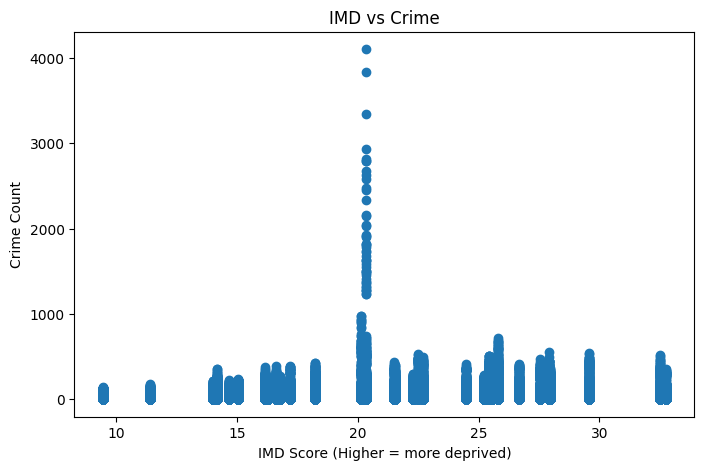

In [104]:
plt.figure(figsize=(8,5))
plt.scatter(borough_merged["IMD - Average score "], borough_merged["Crime_Count"])
plt.xlabel("IMD Score (Higher = more deprived)")
plt.ylabel("Crime Count")
plt.title("IMD vs Crime")
plt.show


In [105]:
borough_merged = borough_merged.to_csv("Borough_merged_IMD_Crime.csv", index=False)